## Importation des librairies

In [1]:
import os
import sys
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure UTF-8 output on Windows terminals
try:
    sys.stdout.reconfigure(encoding='utf-8')
    sys.stderr.reconfigure(encoding='utf-8')
except Exception:
    pass

# Reduce TensorFlow/Abseil logs that may include non-ASCII
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

'2'

## Data preprocessing

### - Training image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels = 'inferred',
    label_mode = "categorical",
    class_names = None,
    color_mode = "rgb",
    batch_size = 32,
    image_size = [128, 128] ,
    shuffle = True,
    seed = None,
    validation_split = None ,
    subset =None ,
    interpolation = 'bilinear',
    follow_links = False ,
    crop_to_aspect_ratio = False,
)

Found 20349 files belonging to 15 classes.


### - Validation image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels = 'inferred',
    label_mode = "categorical",
    class_names = None,
    color_mode = "rgb",
    batch_size = 32,
    image_size = [128, 128] ,
    shuffle = True,
    seed = None,
    validation_split = None ,
    subset =None ,
    interpolation = 'bilinear',
    follow_links = False ,
    crop_to_aspect_ratio = False,
)

Found 244 files belonging to 15 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))>

## Building Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout, Input

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    Conv2D(512, (3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2)),

    Dropout(0.25),
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(15, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        15,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,252,911 (20.04 MB)

 Trainable params: 5,252,911 (20.04 MB)

 Non-trainable params: 0 (0.00 B)

### To Avoid overshooting
1. Choose small learinng rate default O.OO1 we're taking 0.0001
2. There may be chance of underfiting, so increase number of neurone
3. Add more convolution layers to extract more feature from images there may be possibillity that model unable to capture feature or model is confusing due to lack of feature so feed with more feature 

In [6]:
training_history = model.fit(x=training_set, epochs=10, validation_data=validation_set)

Epoch 1/10


636/636 ━━━━━━━━━━━━━━━━━━━━ 828s 1s/step - accuracy: 0.2979 - loss: 2.1775 - val_accuracy: 0.7377 - val_loss: 0.8371
Epoch 2/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.7349 - loss: 0.7876 - val_accuracy: 0.7951 - val_loss: 0.6116
Epoch 3/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.8475 - loss: 0.4512 - val_accuracy: 0.8770 - val_loss: 0.3628
Epoch 4/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.8899 - loss: 0.3240 - val_accuracy: 0.9221 - val_loss: 0.2439
Epoch 5/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 655s 1s/step - accuracy: 0.9240 - loss: 0.2317 - val_accuracy: 0.9180 - val_loss: 0.1851
Epoch 6/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 663s 1s/step - accuracy: 0.9351 - loss: 0.1996 - val_accuracy: 0.9467 - val_loss: 0.1743
Epoch 7/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 742s 1s/step - accuracy: 0.9488 - loss: 0.1522 - val_accuracy: 0.9426 - val_loss: 0.1920
Epoch 8/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 3564s 6s/step - accuracy: 0.9519 - loss: 0.1401 - val_accuracy: 0.91

## Model Evaluation

In [7]:
train_loss, train_acc = model.evaluate(training_set)
print(train_loss, train_acc)


636/636 ━━━━━━━━━━━━━━━━━━━━ 158s 249ms/step - accuracy: 0.9658 - loss: 0.0975
0.09031468629837036 0.9682047963142395


In [8]:
train_loss, train_acc = model.evaluate(validation_set)
print(train_loss, train_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.9435 - loss: 0.1790
0.1693262904882431 0.9508196711540222


In [9]:
model.save('training_model.keras')
training_history.history

{'accuracy': [0.4756990373134613,
  0.7726178169250488,
  0.8636296391487122,
  0.9022064805030823,
  0.9255491495132446,
  0.9376382231712341,
  0.9500712752342224,
  0.954444944858551,
  0.9612757563591003,
  0.9684996604919434],
 'loss': [1.6060196161270142,
  0.6777982711791992,
  0.40399155020713806,
  0.2919188439846039,
  0.22608114778995514,
  0.18559445440769196,
  0.1489831656217575,
  0.13522087037563324,
  0.11537391692399979,
  0.09319388121366501],
 'val_accuracy': [0.7377049326896667,
  0.7950819730758667,
  0.8770492076873779,
  0.9221311211585999,
  0.9180327653884888,
  0.9467213153839111,
  0.9426229596138,
  0.9139344096183777,
  0.9426229596138,
  0.9508196711540222],
 'val_loss': [0.8370756506919861,
  0.6115880608558655,
  0.3627760410308838,
  0.24388223886489868,
  0.18505285680294037,
  0.17431780695915222,
  0.191986545920372,
  0.2057221382856369,
  0.1594322770833969,
  0.1693262755870819]}

In [10]:
# Recording history in json
import json

with open("training_hist.json", "w") as f :
    json.dump(training_history.history, f)

## Accuracy Visualization

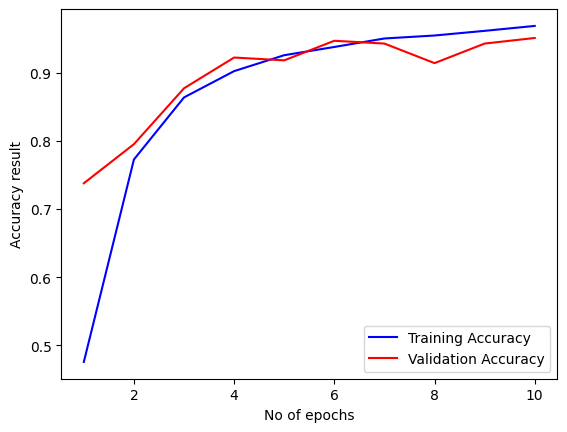

In [11]:
epochs  = [i for i in range(1,11)]

plt.plot(epochs, training_history.history["accuracy"], color='blue', label= "Training Accuracy")
plt.plot(epochs, training_history.history["val_accuracy"], color='red', label= "Validation Accuracy")
plt.xlabel('No of epochs')
plt.ylabel('Accuracy result')
plt.legend()
plt.show()

## Some other metrics for evaluation

In [ ]:
# Charger le modèle s'il n'est pas déjà chargé
try:
    # Vérifier si le modèle existe dans la mémoire
    _ = model.summary()
    print("✓ Modèle déjà chargé en mémoire")
except (NameError, AttributeError):
    # Charger le modèle depuis le fichier sauvegardé
    print("⚠️  Chargement du modèle depuis training_model.keras...")
    model = tf.keras.models.load_model('training_model.keras')
    print("✓ Modèle chargé avec succès")

# Créer le dataset de test (identique à validation_set mais sans shuffle pour l'évaluation)
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels = 'inferred',
    label_mode = "categorical",
    class_names = None,
    color_mode = "rgb",
    batch_size = 32,
    image_size = [128, 128] ,
    shuffle = False,
    seed = None,
    validation_split = None ,
    subset =None ,
    interpolation = 'bilinear',
    follow_links = False ,
    crop_to_aspect_ratio = False,
)
print("✓ Dataset de test créé")

Found 244 files belonging to 15 classes.


In [13]:
predicted_categories = model.predict(test_set)

predicted_categories, predicted_categories.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step


(array([[6.3932664e-03, 1.1852854e-05, 5.0548977e-08, ..., 2.3994703e-08,
         1.8994240e-11, 2.1699312e-10],
        [9.9714702e-01, 2.7297332e-03, 1.0376402e-08, ..., 1.3549115e-07,
         8.1573687e-10, 5.7930891e-09],
        [9.9999273e-01, 2.5554264e-08, 8.9244448e-14, ..., 4.8063771e-06,
         2.4030906e-14, 1.2907257e-13],
        ...,
        [6.3265935e-07, 3.0204459e-04, 2.5966538e-05, ..., 2.5770673e-06,
         1.1285159e-06, 9.9758220e-01],
        [2.2767131e-06, 8.8159459e-06, 5.8468435e-05, ..., 4.5415063e-06,
         2.7262557e-05, 9.4339478e-01],
        [6.5621066e-08, 1.9688790e-07, 3.4654456e-06, ..., 1.6071181e-07,
         2.6298128e-06, 9.8266417e-01]], dtype=float32),
 (244, 15))

In [14]:
y_pred = tf.argmax(predicted_categories, axis = 1)
y_pred

<tf.Tensor: shape=(244,), dtype=int64, numpy=
array([ 6,  0,  0,  0,  0,  0,  7,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  3,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  5,  5,  5,  5,  6,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  6,  6,  6,  6,  6,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7, 12,  7,  7,  7,  7,  7,  8,  9,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,
        8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 11, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13,

In [15]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(244, 15), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [16]:
y = tf.argmax(true_categories, axis = 1)
y

<tf.Tensor: shape=(244,), dtype=int64, numpy=
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13,

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

class_name = validation_set.class_names

print(classification_report(y, y_pred, target_names= class_name))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      0.85      0.92        13
                     Pepper__bell___healthy       1.00      1.00      1.00        13
                      Potato___Early_blight       1.00      1.00      1.00        14
                       Potato___Late_blight       0.94      1.00      0.97        17
                           Potato___healthy       1.00      0.92      0.96        12
                      Tomato_Bacterial_spot       1.00      0.94      0.97        16
                        Tomato_Early_blight       0.82      0.93      0.88        15
                         Tomato_Late_blight       0.83      0.94      0.88        16
                           Tomato_Leaf_Mold       0.94      0.94      0.94        18
                  Tomato_Septoria_leaf_spot       0.93      0.93      0.93        14
Tomato_Spider_mites_Two_spotted_spider_mite       1.00      0.96

## Détection sain/malade avec YOLO


Cette section ajoute un pipeline complet pour transformer le dataset de classification existant en annotations de détection binaire (`healthy` vs `diseased`), entraîner YOLO, puis évaluer et visualiser les prédictions. Les étapes principales sont :

1. Installer Ultralytics (implémentation officielle de YOLOv8).
2. Convertir le dataset `train/` – `valid/` vers le format YOLO en créant des boîtes englobantes pleine image.
3. Générer le fichier `data.yaml` et lancer l'entraînement.
4. Valider et sauvegarder des exemples d'inférence pour inspection visuelle.


In [7]:
from pathlib import Path
from shutil import copy2
import yaml

# Définition des chemins
source_root = Path('.')
source_splits = {
    'train': source_root / 'train',
    'val': source_root / 'valid'
}
yolo_root = source_root / 'yolo_dataset'
images_root = yolo_root / 'images'
labels_root = yolo_root / 'labels'

healthy_keywords = ['healthy']  # clés simples pour marquer les classes saines

# Nettoyage simple
if yolo_root.exists():
    # On garde les runs précédents pour comparaison, donc pas de suppression totale
    print('⚠️  Le dossier yolo_dataset existe déjà : seuls les nouveaux fichiers seront écrasés.')

yolo_root.mkdir(parents=True, exist_ok=True)
(images_root / 'train').mkdir(parents=True, exist_ok=True)
(images_root / 'val').mkdir(parents=True, exist_ok=True)
(labels_root / 'train').mkdir(parents=True, exist_ok=True)
(labels_root / 'val').mkdir(parents=True, exist_ok=True)

class_names = sorted([d.name for d in source_splits['train'].iterdir() if d.is_dir()])
healthy_classes = {
    cls: any(key in cls.lower() for key in healthy_keywords)
    for cls in class_names
}
print(f"Classes détectées ({len(class_names)}): {class_names}")
print(f"Classes saines: {[cls for cls, is_h in healthy_classes.items() if is_h]}")

stats = {split: {'healthy': 0, 'diseased': 0, 'images': 0} for split in source_splits}

for split, split_dir in source_splits.items():
    if not split_dir.exists():
        raise FileNotFoundError(f"Le dossier {split_dir} est introuvable")

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        label_id = 0 if healthy_classes.get(class_dir.name, False) else 1
        label_name = 'healthy' if label_id == 0 else 'diseased'

        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
                continue

            dest_img = images_root / split / img_path.name
            dest_lbl = labels_root / split / (img_path.stem + '.txt')

            copy2(img_path, dest_img)
            dest_lbl.write_text(f"{label_id} 0.5 0.5 1.0 1.0\n")

            stats[split]['images'] += 1
            stats[split][label_name] += 1

for split, values in stats.items():
    print(f"{split}: {values['images']} images -> {values['healthy']} healthy / {values['diseased']} diseased")

# Génération de data.yaml
names = ['healthy', 'diseased']
data_yaml = {
    'path': str(yolo_root.resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'names': names
}
with open(yolo_root / 'data.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("Fichier data.yaml généré:")
print(yolo_root / 'data.yaml')


⚠️  Le dossier yolo_dataset existe déjà : seuls les nouveaux fichiers seront écrasés.
Classes détectées (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Classes saines: ['Pepper__bell___healthy', 'Potato___healthy', 'Tomato_healthy']
train: 20349 images -> 3168 healthy / 17181 diseased
val: 244 images -> 46 healthy / 198 diseased
Fichier data.yaml généré:
yolo_dataset\data.yaml


In [4]:
from ultralytics import YOLO
from pathlib import Path

source_root = Path('.')
yolo_root = source_root / 'yolo_dataset'

yolo_model = YOLO('yolov8n.pt') 
train_results = yolo_model.train(
    data=str(yolo_root / 'data.yaml'),
    epochs=3,
    imgsz=640,
    batch=16,
    name='plant-health-detector',
    project='runs/detect',
    lr0=5e-4,
    lrf=5e-5,
    optimizer='AdamW',
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=0.8,
    mixup=0.15,
    patience=15,
    close_mosaic=10,
    pretrained=True
)
train_results


Ultralytics 8.3.228  Python-3.10.0 torch-2.7.1+cpu CPU (12th Gen Intel Core i7-1265U)


engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=5e-05, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=plant-health-detector3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=runs/detect, rect=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C377DC8880>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [5]:
val_metrics = yolo_model.val()
val_metrics


Ultralytics 8.3.228  Python-3.10.0 torch-2.7.1+cpu CPU (12th Gen Intel Core i7-1265U)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 268.682.6 MB/s, size: 14.0 KB)
val: Scanning D:\DeepProject\PlantVillage\yolo_dataset\labels\val.cache... 244 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 244/244  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.4s/it 22.2s1.5s
                   all        244        244      0.994      0.999      0.995      0.995
               healthy         46         46      0.988          1      0.995      0.995
              diseased        198        198          1      0.998      0.995      0.995
Speed: 1.4ms preprocess, 83.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to D:\DeepProject\PlantVillage\runs\detect\val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C375C5A2C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [9]:
preview_dir = Path('runs/detect/plant-health-preview')
preview_dir.mkdir(parents=True, exist_ok=True)

predictions = yolo_model.predict(
    source=str((yolo_root / 'images' / 'val').resolve()),
    imgsz=640,
    conf=0.25,
    save=True,
    project='runs/detect',
    name='plant-health-preview',
    exist_ok=True
)
print(f"Visualisations sauvegardées dans: {preview_dir.resolve()}")



image 1/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\03882a7e-b80a-4c12-b4bb-5d03c88a8c4b___Com.G_SpM_FL 8730.JPG: 640x640 1 diseased, 190.6ms
image 2/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\2960d2b0-5db9-4112-89f6-c7c0d2f01b97___Com.G_SpM_FL 8806.JPG: 640x640 1 diseased, 102.2ms
image 3/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\3046afbf-4a9a-41fb-a64f-3f9e75af08e7___Com.G_SpM_FL 1623.JPG: 640x640 1 diseased, 106.1ms
image 4/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\3049a6ad-905d-4a96-92b4-2ec045c397a1___Com.G_SpM_FL 8796.JPG: 640x640 1 diseased, 107.9ms
image 5/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\3156e176-2697-4be0-8cc7-37ce05aade4b___Com.G_SpM_FL 1431.JPG: 640x640 1 diseased, 101.4ms
image 6/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\3181e984-bdb0-403d-9f58-a259535cb4d4___Com.G_SpM_FL 1405.JPG: 640x640 1 diseased, 110.7ms
image 7/244 D:\DeepProject\PlantVillage\yolo_dataset\images\val\3237c6fb-59

**Notes d'utilisation**

- Les boîtes englobantes occupent toute l'image : cela reste cohérent avec un diagnostic feuille/plante mais n'empêche pas d'ajouter des annotations précises plus tard.
- Ajuster `healthy_keywords` si certaines classes doivent être re-étiquetées (par exemple, des maladies spécifiques considérées comme « saines » dans certains scénarios).
- Pour améliorer la précision :
  - Passer sur `yolov8s.pt` / `yolov8m.pt`.
  - Augmenter le nombre d'époques ou fournir de véritables boîtes d'intérêt.
  - Ajouter un split `test` séparé et tracer les métriques (PR curve, F1 vs conf, etc.).


In [10]:
cm  = confusion_matrix(y, y_pred)
cm

NameError: name 'confusion_matrix' is not defined

## Confusion matrix visualization

<Axes: >

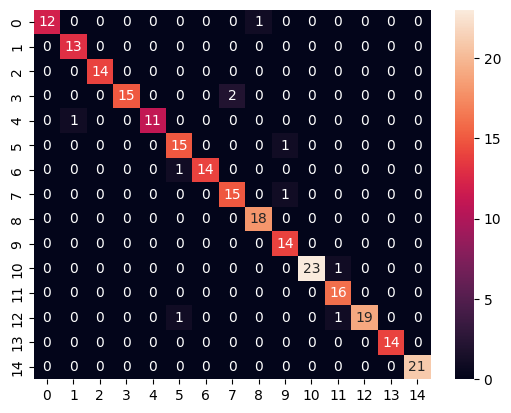

In [ ]:
sns.heatmap(cm, annot = True)